In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.utils import to_scipy_sparse_matrix
from vqniche.dataloaders.in_memory_dataset_blob import InMemoryDatasetBlob

/lustre/scratch126/cellgen/team361/am84/conda/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_directory_path = '/lustre/scratch126/cellgen/team361/DATASETS'
dataset_name = 'sss2-1b_1p' # xhs1000-39b_1p (Lloyd's skin dataset)
dataset_blob = InMemoryDatasetBlob(
                    name=dataset_name,
                    data_directory_path=data_directory_path,
                )

In [3]:
batch_id = 0
data_batch = dataset_blob[batch_id]
data_batch

Data(x_cell_gene_counts=[10000, 1105], y_cell_types=[10000, 8], y_niche_types=[10000, 8], edge_index_spatial_delaunay_radius_27.5=[2, 69944], edge_index_spatial_delaunay_radius_55.0=[2, 69944], edge_index_spatial_delaunay=[2, 69944], edge_index_spatial_n_neighs_10_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_20_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_30_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_10_radius_55.0=[2, 211818], edge_index_spatial_n_neighs_20_radius_55.0=[2, 211818], edge_index_spatial_n_neighs_30_radius_55.0=[2, 211818], edge_index_spatial_n_neighs_10=[2, 110000], edge_index_spatial_n_neighs_20=[2, 210000], edge_index_spatial_n_neighs_30=[2, 310000])

In [4]:
graphs = {}
for key, value in data_batch.items():
    if key.startswith('edge_index_'):
        print(key)
        adj_sp = to_scipy_sparse_matrix(value)
        graphs[key] = nx.from_scipy_sparse_array(adj_sp)

edge_index_spatial_delaunay_radius_27.5
edge_index_spatial_delaunay_radius_55.0
edge_index_spatial_delaunay
edge_index_spatial_n_neighs_10_radius_27.5
edge_index_spatial_n_neighs_20_radius_27.5
edge_index_spatial_n_neighs_30_radius_27.5
edge_index_spatial_n_neighs_10_radius_55.0
edge_index_spatial_n_neighs_20_radius_55.0
edge_index_spatial_n_neighs_30_radius_55.0
edge_index_spatial_n_neighs_10
edge_index_spatial_n_neighs_20
edge_index_spatial_n_neighs_30


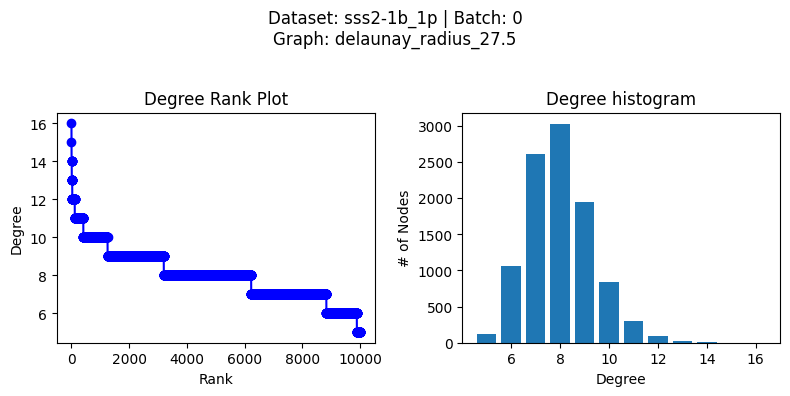

In [6]:
edge_index_name = 'edge_index_spatial_delaunay_radius_27.5'

G = graphs[edge_index_name]
degree_sequence = sorted((d for _, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(8, 4))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(axgrid[:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.suptitle(f"Dataset: {dataset_name} | Batch: {batch_id}\nGraph: {edge_index_name[19:]}")

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()